<a href="https://colab.research.google.com/github/AdrianoLusso/clases_computacionCuantica/blob/main/taller_cuantico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Taller de Computacion Cuantica: ponete a jugar con qubits

## De la teoria a las manos en 25 minutos

En la charla vimos qudits, superposicion, optimizacion combinatoria y QAOA. Ahora te toca **ejecutar** algo de eso vos.

**Reglas del juego:**

- Las celdas ya estan casi listas. Vos solo tenes que **ejecutar** (Shift + Enter) y, donde diga `>>> COMPLETA AQUI`, cambiar un valor y volver a correr.
- No necesitas saber fisica cuantica. Necesitas curiosidad.
- Si algo se rompe: `Entorno de ejecucion > Reiniciar y ejecutar todo`.

**Recorrido de hoy:**

1. Calentamiento: tu primera moneda cuantica (1 qubit).
2. QAOA: resolver un problema de optimizacion como en la investigacion del JRP.
3. Quantum Machine Learning: entrenar un clasificador cuantico.
4. Super ultra reto final.

Arranquemos.

## 0. Setup (corre esto primero)

Instalamos **PennyLane** (el framework cuantico que vamos a usar) y un par de librerias auxiliares. Tarda ~30 segundos.

In [13]:
!pip install -q pennylane networkx scikit-learn matplotlib
print("Listo. Librerias instaladas.")

Listo. Librerias instaladas.


## 1. Calentamiento: tu primera moneda cuantica

Un **qubit** es como una moneda, pero antes de mirarla puede estar en **superposicion**: una mezcla de "cara" (0) y "cruz" (1) al mismo tiempo.

La compuerta `RY(theta)` nos deja controlar cuanta probabilidad le damos a cada cara girando la moneda un angulo `theta`.

- `theta = 0` -> siempre sale 0.
- `theta = pi` -> siempre sale 1.
- `theta = pi/2` -> 50% y 50% (superposicion perfecta).

Ejecuta la celda y despues cambia `theta`.

P(cara=0) = 0.50   |   P(cruz=1) = 0.50


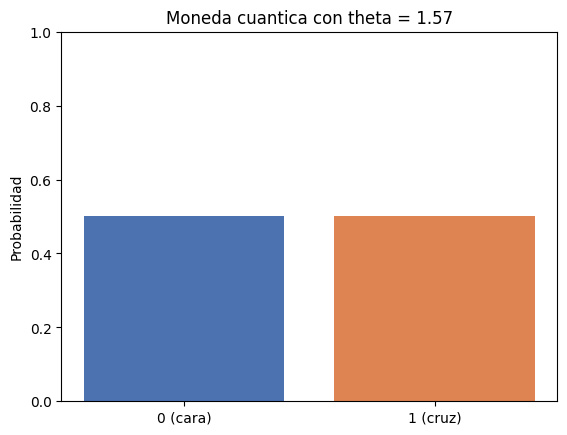

In [14]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Un "dispositivo" cuantico simulado con 1 qubit
dev1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev1)
def moneda_cuantica(theta):
    qml.RY(theta, wires=0)        # giramos la moneda
    return qml.probs(wires=0)     # probabilidad de 0 y de 1

# >>> COMPLETA AQUI: proba con 0, np.pi, np.pi/2, np.pi/4 ...
theta = np.pi / 2

probs = moneda_cuantica(theta)
print(f"P(cara=0) = {probs[0]:.2f}   |   P(cruz=1) = {probs[1]:.2f}")

plt.bar(["0 (cara)", "1 (cruz)"], probs, color=["#4C72B0", "#DD8452"])
plt.ylim(0, 1)
plt.title(f"Moneda cuantica con theta = {theta:.2f}")
plt.ylabel("Probabilidad")
plt.show()

**Lo que acaba de pasar:** definiste un circuito cuantico real (sobre un simulador). `theta` controla la superposicion. Esto mismo, con muchos qubits y muchas compuertas, es lo que permite los algoritmos que vienen ahora.

Pregunta rapida: que valor de `theta` te da la moneda mas "injusta" posible (casi siempre 1)?

## 2. QAOA: optimizar como en el problema del JRP

En la charla aparecio **QAOA** para resolver problemas de **optimizacion combinatoria** (como el *Job Reassignment Problem*). La idea: hay muchisimas combinaciones posibles y queremos la mejor.

Vamos con un clasico mas chico: **Max-Cut**. Dado un grafo, queremos pintar cada nodo de uno de dos colores de modo que **sse maximice la cantidad de aristas que empiezan en un nodo de un color y terminan en el nodo de otro color**.

Primero armamos el grafo.

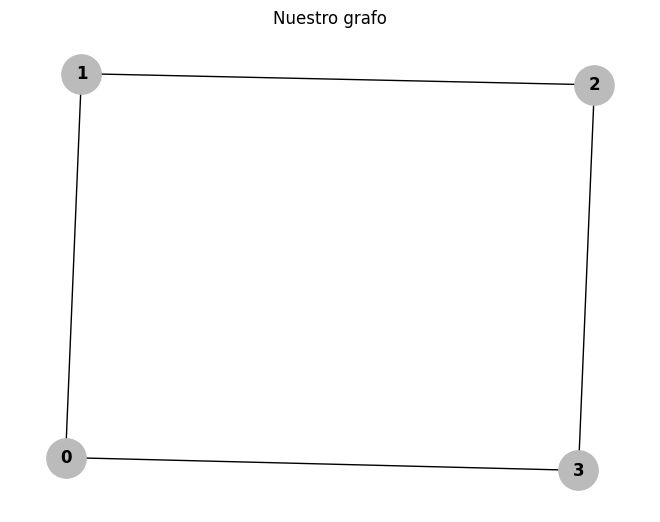

In [17]:
import networkx as nx

# Grafo de 4 nodos. Cada tupla es una conexion (arista).
# >>> COMPLETA AQUI: mas tarde proba agregar o quitar aristas, ej: (0, 2)
aristas = [(0, 1), (1, 2), (2, 3), (3, 0)]

grafo = nx.Graph(aristas)
n_nodos = grafo.number_of_nodes()

nx.draw(grafo, with_labels=True, node_color="#BBBBBB", node_size=800, font_weight="bold")
plt.title("Nuestro grafo")
plt.show()

Ahora construimos el circuito QAOA. PennyLane nos da los "ingredientes" automaticamente:

- **Hamiltoniano de costo** (`cost_h`): codifica "cuantas aristas cortamos".
- **Hamiltoniano mezclador** (`mixer_h`): explora distintas soluciones.

El circuito alterna capas de costo (parametro `gamma`) y mezcla (parametro `beta`), tal cual lo vimos en las laminas.

In [21]:
from pennylane import qaoa

cost_h, mixer_h = qaoa.maxcut(grafo)
wires = range(n_nodos)

# >>> COMPLETA AQUI: profundidad del QAOA. Proba con 1, 2 o 3 capas.
p_capas = 2

def capa_qaoa(gamma, beta):
    qaoa.cost_layer(gamma, cost_h)
    qaoa.mixer_layer(beta, mixer_h)

def circuito(params):
    for w in wires:
        qml.Hadamard(wires=w)           # empezamos en superposicion total
    qml.layer(capa_qaoa, p_capas, params[0], params[1])

dev_q = qml.device("default.qubit", wires=n_nodos)

@qml.qnode(dev_q)
def costo(params):
    circuito(params)
    return qml.expval(cost_h)

print("Circuito QAOA listo con", p_capas, "capa(s).")

Circuito QAOA listo con 2 capa(s).


In [27]:
# para visualizar
class PhaseSeparator(qml.ApproxTimeEvolution):
    def label(self, decimals=None, base_label=None, cache=None):
        return "Phase"

class Mixer(qml.ApproxTimeEvolution):
    def label(self, decimals=None, base_label=None, cache=None):
        return "Mix"

def capa_qaoa(gamma, beta):
    PhaseSeparator(cost_h, gamma, 1)
    Mixer(mixer_h, beta, 1)

@qml.qnode(dev_q)
def mostrar(params):
    circuito(params)
    return qml.state()

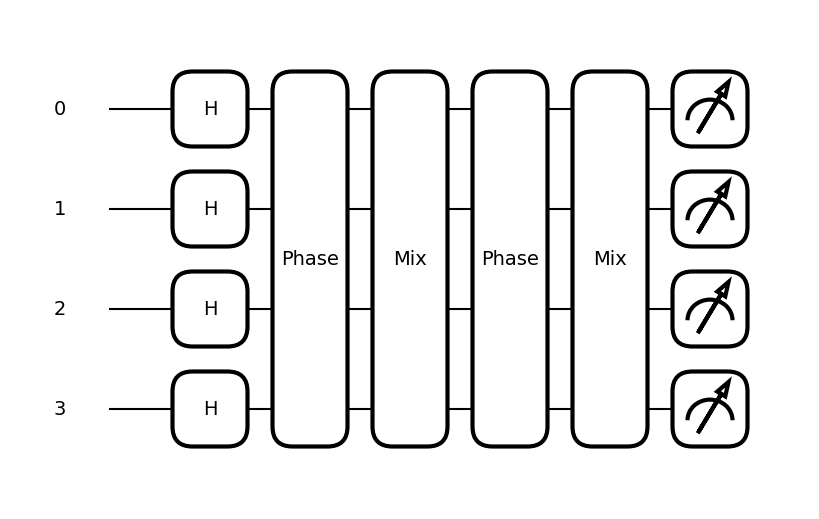

In [30]:
# visualizar circuito
np.random.seed(42)
params = 0.5 * np.ones((2, p_capas), requires_grad=True)

fig, ax = qml.draw_mpl(mostrar)(params)
plt.show()

Entrenamos: ajustamos `gamma` y `beta` con un optimizador (descenso por gradiente) para **minimizar el costo**, que equivale a **maximizar las aristas cortadas**.

Paso  10 | costo = -3.2927
Paso  20 | costo = -3.9292
Paso  30 | costo = -3.9122
Paso  40 | costo = -3.9824
Paso  50 | costo = -3.9898
Paso  60 | costo = -3.9968


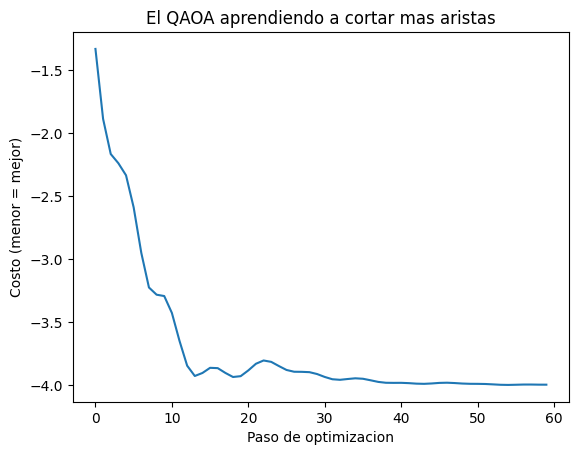

In [31]:
np.random.seed(42)
params = 0.5 * np.ones((2, p_capas), requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.1)

# >>> COMPLETA AQUI: pasos de optimizacion. Mas pasos = mejor (y mas lento). Proba 30, 60, 100.
pasos = 60

historial = []
for i in range(pasos):
    params, valor = opt.step_and_cost(costo, params)
    historial.append(valor)
    if (i + 1) % 10 == 0:
        print(f"Paso {i+1:3d} | costo = {valor:.4f}")

plt.plot(historial)
plt.xlabel("Paso de optimizacion")
plt.ylabel("Costo (menor = mejor)")
plt.title("El QAOA aprendiendo a cortar mas aristas")
plt.show()

Por ultimo, **leemos la solucion**: medimos muchas veces y nos quedamos con la combinacion mas probable. Esa es la mejor particion del grafo que encontro el algoritmo cuantico.

Mejor solucion encontrada: 0101  ->  aristas cortadas: 4 de 4


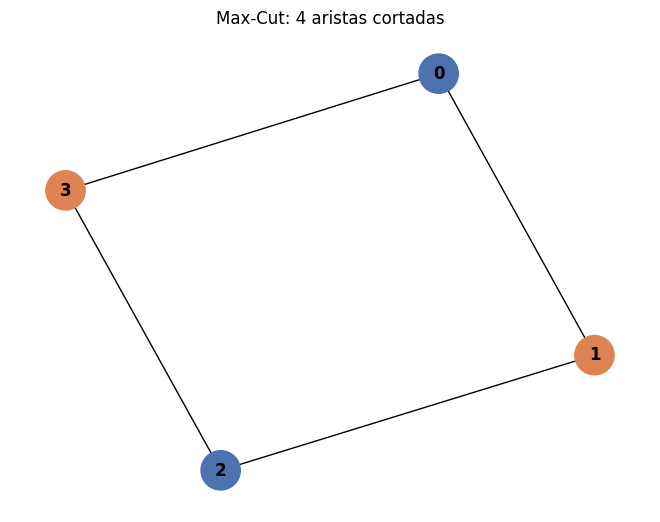

In [32]:
@qml.qnode(dev_q)
def distribucion(params):
    circuito(params)
    return qml.probs(wires=wires)

probs = distribucion(params)
mejor = int(np.argmax(probs))
bits = format(mejor, f"0{n_nodos}b")
colores = ["#DD8452" if b == "1" else "#4C72B0" for b in bits]

cortadas = sum(1 for u, v in grafo.edges if bits[u] != bits[v])
print(f"Mejor solucion encontrada: {bits}  ->  aristas cortadas: {cortadas} de {grafo.number_of_edges()}")

nx.draw(grafo, with_labels=True, node_color=colores, node_size=800, font_weight="bold")
plt.title(f"Max-Cut: {cortadas} aristas cortadas")
plt.show()

Acabas de correr el **mismo tipo de algoritmo** que se investiga para problemas reales de asignacion de tareas (el JRP de la charla). Cambia las aristas, las capas o los pasos y mira como cambia la solucion.

---

## 3. Quantum Machine Learning: un clasificador cuantico

Ultima parada. En la charla aparecio **QML**: usar circuitos cuanticos como modelos de machine learning que se **entrenan**, igual que una red neuronal.

Vamos a clasificar dos grupos de puntos con forma de medialunas. El circuito:

1. **Codifica** cada punto (x, y) en angulos de qubits (`AngleEmbedding`).
2. **Procesa** con compuertas entrelazadas y parametros entrenables (`BasicEntanglerLayers`).
3. **Decide** la clase midiendo un qubit.

Un truco clave: repetimos la codificacion en cada capa (*data re-uploading*), lo que le da al circuito mas poder para separar formas curvas.

Primero, los datos.

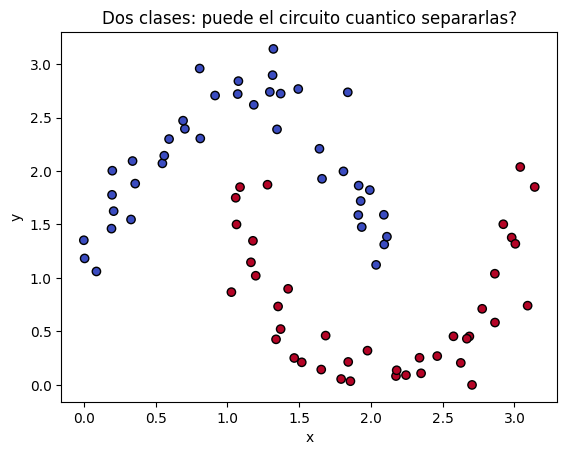

In [38]:
from sklearn.datasets import make_moons,make_circles
from sklearn.preprocessing import MinMaxScaler

X, y = make_moons(n_samples=80, noise=0.1, random_state=0)
y = y * 2 - 1                                  # etiquetas en {-1, +1}, comodo para lo cuantico
X = MinMaxScaler((0, np.pi)).fit_transform(X)  # escalamos a angulos [0, pi]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.title("Dos clases: puede el circuito cuantico separarlas?")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [35]:
n_qubits = 2

# >>> COMPLETA AQUI: capas del clasificador (repiten codificacion + entrelazado). Proba 3, 4, 5.
n_capas = 4

dev_ml = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_ml)
def clasificador(pesos, x):
    for capa in range(n_capas):
        qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")            # codifica el punto
        qml.BasicEntanglerLayers(pesos[capa:capa+1], wires=range(n_qubits))  # parte entrenable
    return qml.expval(qml.PauliZ(0))                                          # salida en [-1, 1]

def modelo(pesos, sesgo, x):
    return clasificador(pesos, x) + sesgo

def costo_ml(pesos, sesgo, X, Y):
    preds = np.array([modelo(pesos, sesgo, x) for x in X])
    return np.mean((Y - preds) ** 2)

def precision(pesos, sesgo, X, Y):
    preds = np.array([np.sign(modelo(pesos, sesgo, x)) for x in X])
    return np.mean(preds == Y)

print("Modelo de QML definido con", n_capas, "capas.")

Modelo de QML definido con 4 capas.


In [36]:
np.random.seed(0)

pesos = 0.1 * np.random.randn(n_capas, n_qubits, requires_grad=True)
sesgo = np.array(0.0, requires_grad=True)

opt_ml = qml.AdamOptimizer(stepsize=0.3)

# >>> COMPLETA AQUI: epocas de entrenamiento. Proba 40, 60, 80.
epocas = 60

for it in range(epocas):
    (pesos, sesgo, _, _), c = opt_ml.step_and_cost(costo_ml, pesos, sesgo, X, y)
    if (it + 1) % 10 == 0:
        acc = precision(pesos, sesgo, X, y)
        print(f"Epoca {it+1:3d} | costo = {c:.4f} | precision = {acc:.0%}")

print(f"\nPrecision final: {precision(pesos, sesgo, X, y):.0%}")

Epoca  10 | costo = 1.0035 | precision = 56%
Epoca  20 | costo = 0.8452 | precision = 74%
Epoca  30 | costo = 0.8484 | precision = 70%
Epoca  40 | costo = 0.8254 | precision = 72%
Epoca  50 | costo = 0.8192 | precision = 75%
Epoca  60 | costo = 0.8162 | precision = 70%

Precision final: 70%


Dibujemos la **frontera de decision** que aprendio el circuito cuantico.

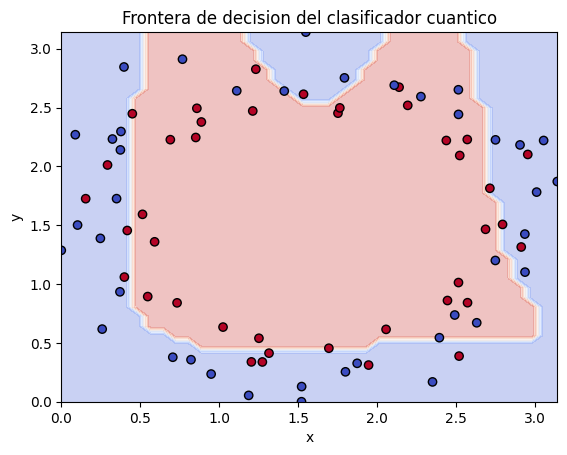

In [37]:
import numpy as np_clasico   # numpy normal, solo para armar la grilla del dibujo

xs = np_clasico.linspace(0, np.pi, 40)
xx, yy = np_clasico.meshgrid(xs, xs)
grid = np_clasico.c_[xx.ravel(), yy.ravel()]
Z = np_clasico.array([float(np.sign(modelo(pesos, sesgo, p))) for p in grid]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.title("Frontera de decision del clasificador cuantico")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Entrenaste un modelo de **machine learning cuantico** de punta a punta: codificacion de datos, parametros entrenables y optimizacion por gradiente. Esto es exactamente la familia de ideas del slide de QML de la charla.

---

## 4. Reto final

Ahora te toca a vos. Elegi **al menos uno** (o los tres si te enganchaste):

1. **QAOA:** agrega la arista `(0, 2)` al grafo y volve a entrenar. Cuantas aristas se cortan ahora? Cambia tambien `p_capas`.
2. **QML:** llega a **90% o mas** de precision tocando `n_capas`, `epocas` o el `stepsize`. Probaste con `make_circles` en vez de `make_moons`?
3. **Moneda:** encontra el `theta` que da exactamente 25% de probabilidad de salir 1.

## Esto te gusto? Es solo el principio

Hoy tocaste superposicion, QAOA y QML en 25 minutos. En el **taller** vamos mas profundo: ruido, qudits, problemas reales de optimizacion y como llevarlo a hardware cuantico de verdad.

Llevate este notebook, rompelo, mejoralo y traelo con preguntas. Nos vemos en el taller.